Data Loaded: (17600, 163)
Data Loaded (after filter): (14784, 163)


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.


Sound Ratings Processed: (420, 14) (Subject x Sound 단위)

[Sound Perception PCA]
- Selected Components: 7 (Threshold >= 90.0%)
- Explained Variance Ratio: [0.465 0.162 0.133 0.046 0.039 0.033 0.031]
- Cumulative Variance: [0.465 0.627 0.76  0.806 0.845 0.878 0.909]


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

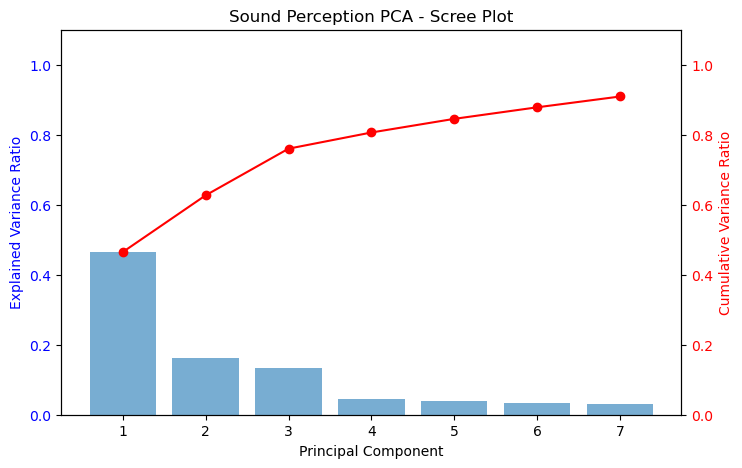

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Fon

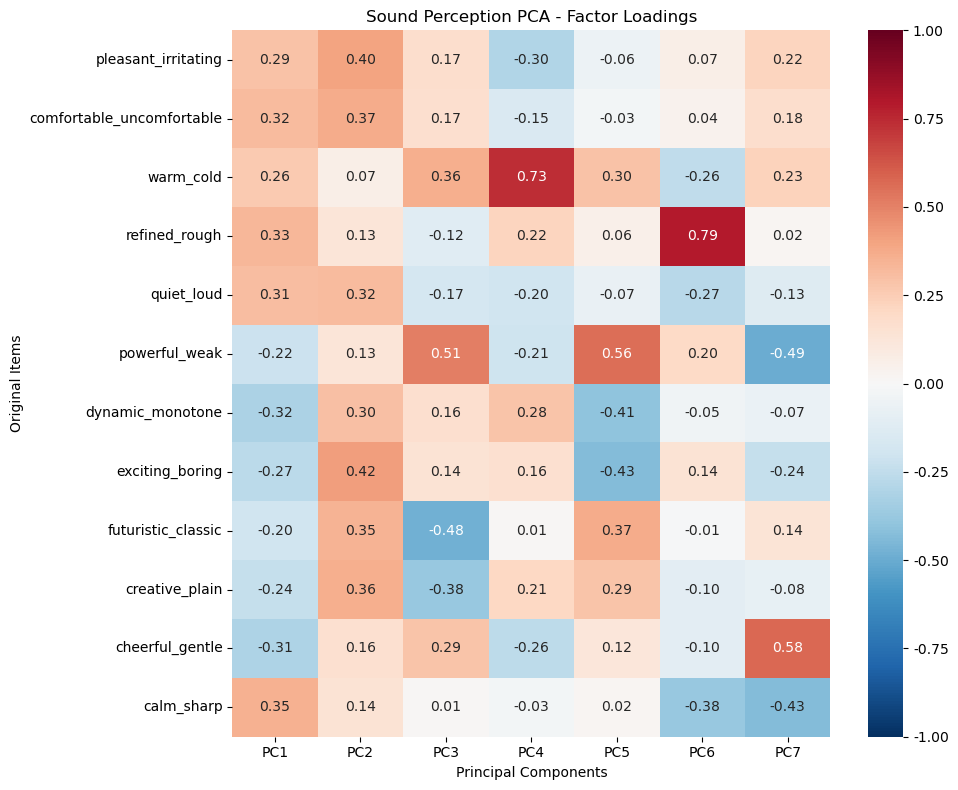

                                PC1       PC2       PC3       PC4       PC5  \
pleasant_irritating        0.290791  0.399530  0.174058 -0.298087 -0.060341   
comfortable_uncomfortable  0.315613  0.369932  0.165267 -0.154217 -0.025533   
warm_cold                  0.262835  0.065494  0.362085  0.734518  0.295826   
refined_rough              0.332963  0.131116 -0.121809  0.220309  0.059280   
quiet_loud                 0.311509  0.315698 -0.174637 -0.197287 -0.073052   
powerful_weak             -0.218030  0.128502  0.510874 -0.207020  0.558590   
dynamic_monotone          -0.315076  0.301202  0.164745  0.281675 -0.405347   
exciting_boring           -0.271776  0.415427  0.144885  0.163586 -0.430550   
futuristic_classic        -0.197942  0.351241 -0.478241  0.012873  0.374931   
creative_plain            -0.238420  0.364341 -0.381032  0.209400  0.287027   
cheerful_gentle           -0.312269  0.161343  0.287741 -0.258189  0.119150   
calm_sharp                 0.353037  0.142895  0.011

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

plt.rcParams['font.family'] = 'AppleGothic' 
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 1. Load Data
# ============================================================
csv_path = "dfm_for_lme4_final_with_drowsy.csv"
df = pd.read_csv(csv_path)
print(f"Data Loaded: {df.shape}")

if "subject_id" not in df.columns and "subject" in df.columns:
    df = df.rename(columns={"subject": "subject_id"})

exclude_subjects = [1013, 1025, 1032, 1038, 1053, 1061, 1063, 1077]

df = df[~df["subject_id"].isin(exclude_subjects)].copy()
print(f"Data Loaded (after filter): {df.shape}")
# ============================================================
# 2. Driving Sound perceptual rating data preprocessing (Wide -> Long -> Mean)
#    : The average score per item is calculated in units of (Subject x Sound).
# ============================================================
phrase_map = {
    "조용하거나 시끄럽": "quiet_loud",
    "차분하거나 날카롭": "calm_sharp",
    "기분 좋거나 짜증": "pleasant_irritating",
    "기분좋거나 짜증": "pleasant_irritating",
    "따뜻하거나 차갑": "warm_cold",
    "편안하거나 불편": "comfortable_uncomfortable",
    "힘차거나 약하": "powerful_weak",
    "경쾌하거나 잔잔": "cheerful_gentle",
    "다이나믹하거나 단조": "dynamic_monotone",
    "흥미진진하거나 지루": "exciting_boring",
    "미래적이거나 고전적": "futuristic_classic",
    "창의적이거나 평범": "creative_plain",
    "고상하거나 거칠": "refined_rough",
}

rating_cols = [c for c in df.columns if "번 주행음" in c]
long_rows = []

for _, row in df.iterrows():
    subj = row["subject_id"]
    for col in rating_cols:
        m = re.search(r"(\d+)번\s*주행음", col)
        if not m: continue
        sound_id = int(m.group(1))

        item_key = None
        for snippet, key in phrase_map.items():
            if snippet in col:
                item_key = key
                break
        
        val = row[col]
        if item_key and pd.notna(val):
            long_rows.append({
                "subject_id": subj,
                "sound_id": sound_id,
                "item": item_key,
                "score": float(val)
            })

rating_long = pd.DataFrame(long_rows)
rating_wide = rating_long.pivot_table(
    index=["subject_id", "sound_id"],
    columns="item",
    values="score",
    aggfunc="mean"
).reset_index()

print(f"Sound Ratings Processed: {rating_wide.shape} (Subject x Sound 단위)")

# ============================================================
# 3. PCA analysis & visualization helper
# ============================================================
def run_pca_and_visualize(data, columns, title="PCA Analysis", threshold=0.90):
    """
    데이터와 컬럼 리스트를 받아 PCA를 수행하고,
    1) 적재값(Loadings) 히트맵
    2) 스크리 도표(Scree Plot)
    를 그립니다.
    """
    # 1. Data preparation (Impute -> Standardization)
    X = data[columns].copy()
    X = SimpleImputer(strategy="mean").fit_transform(X) 
    X_std = StandardScaler().fit_transform(X)           

    # 2. PCA 
    pca = PCA(n_components=threshold, svd_solver='full')
    pca_scores = pca.fit_transform(X_std)
    
    n_pcs = pca.n_components_
    pc_names = [f"PC{i+1}" for i in range(n_pcs)]
    
    print(f"\n[{title}]")
    print(f"- Selected Components: {n_pcs} (Threshold >= {threshold*100}%)")
    print(f"- Explained Variance Ratio: {np.round(pca.explained_variance_ratio_, 3)}")
    print(f"- Cumulative Variance: {np.round(pca.explained_variance_ratio_.cumsum(), 3)}")

    # 3. Dataframe of PC loadings
    loadings = pd.DataFrame(
        pca.components_.T, 
        index=columns, 
        columns=pc_names
    )

    # -----------------------------
    # Visualization 1: Scree Plot
    # -----------------------------
    exp_var = pca.explained_variance_ratio_
    cum_var = np.cumsum(exp_var)
    
    fig, ax1 = plt.subplots(figsize=(8, 5))
    x_idx = range(1, n_pcs + 1)
    
    ax1.bar(x_idx, exp_var, alpha=0.6, label='Individual Var')
    ax1.set_xlabel('Principal Component')
    ax1.set_ylabel('Explained Variance Ratio', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_ylim(0, 1.1)

    ax2 = ax1.twinx()
    ax2.plot(x_idx, cum_var, marker='o', color='red', label='Cumulative Var')
    ax2.set_ylabel('Cumulative Variance Ratio', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 1.1)
    
    plt.title(f"{title} - Scree Plot")
    plt.xticks(x_idx)
    plt.grid(axis='x', linestyle='--')
    plt.show()

    # -----------------------------
    # Visualization 2: Loadings Heatmap
    # -----------------------------
    plt.figure(figsize=(10, len(columns) * 0.5 + 2))
    sns.heatmap(loadings, annot=True, cmap="RdBu_r", center=0, fmt=".2f", vmin=-1, vmax=1)
    plt.title(f"{title} - Factor Loadings")
    plt.ylabel("Original Items")
    plt.xlabel("Principal Components")
    plt.tight_layout()
    plt.show()
    print(loadings)
    return pca, loadings, pca_scores

# ============================================================
# 4. Driving Sound PCA
# ============================================================
sound_items = [
    "pleasant_irritating", "comfortable_uncomfortable", "warm_cold", "refined_rough",
    "quiet_loud", "powerful_weak", "dynamic_monotone", "exciting_boring",
    "futuristic_classic", "creative_plain", "cheerful_gentle", "calm_sharp"
]

available_sound_items = [c for c in sound_items if c in rating_wide.columns]

pca_snd, load_snd, score_snd = run_pca_and_visualize(
    rating_wide, 
    available_sound_items, 
    title="Sound Perception PCA"
)

In [2]:
# ===========================================================
# 5. Output BGM (sound_id) rankings by PC (BGM unit)

# - PC score by (subject_id, sound_id) -> Aggregate by sound_id average and sort

# ============================================================

# Since score_snd has the same row order as rating_wide, append (subject_id, sound_id)
pc_names = [f"PC{i+1}" for i in range(pca_snd.n_components_)]

scores_df = rating_wide[["subject_id", "sound_id"]].copy()
scores_df[pc_names] = score_snd  # (n_rows, n_pcs)

# Aggregated by BGM unit (average)
bgm_pc = (
    scores_df
    .groupby("sound_id", as_index=False)[pc_names]
    .mean()
)

# Output BGM from 1st to last place per PC
for pc in pc_names:
    ranked = bgm_pc.sort_values(pc, ascending=False).reset_index(drop=True)
    ranked["rank"] = np.arange(1, len(ranked) + 1)

    print("\n" + "="*60)
    print(f"[{pc}] BGM Ranking (sound_id) 1st -> last (by mean PC score)")
    print("="*60)

    print(ranked[["rank", "sound_id", pc]].to_string(index=False))


out_path = "bgm_rankings_by_pc_mean.csv"
# long format
long_rows = []
for pc in pc_names:
    ranked = bgm_pc.sort_values(pc, ascending=False).reset_index(drop=True)
    for i, row in ranked.iterrows():
        long_rows.append({
            "PC": pc,
            "rank": i + 1,
            "sound_id": int(row["sound_id"]),
            "pc_score_mean": float(row[pc])
        })
pd.DataFrame(long_rows).to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")


[PC1] BGM Ranking (sound_id) 1st -> last (by mean PC score)
 rank  sound_id       PC1
    1         4  1.745895
    2         5  1.628463
    3         6  1.588108
    4         9  0.953986
    5         8  0.573626
    6         2  0.375440
    7        10 -0.364568
    8         3 -0.951065
    9         7 -2.493758
   10         1 -3.056127

[PC2] BGM Ranking (sound_id) 1st -> last (by mean PC score)
 rank  sound_id       PC2
    1        10  1.822465
    2         8  0.267549
    3         7  0.157835
    4         4 -0.018243
    5         6 -0.209952
    6         5 -0.226308
    7         3 -0.239610
    8         9 -0.398237
    9         1 -0.555966
   10         2 -0.599533

[PC3] BGM Ranking (sound_id) 1st -> last (by mean PC score)
 rank  sound_id       PC3
    1         4  1.001279
    2         3  0.875574
    3         1  0.530092
    4         2  0.238396
    5        10  0.228577
    6         9 -0.081743
    7         6 -0.127201
    8         5 -0.442983
    9      